In [4]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect('../olist.duckdb', read_only=True)

## Cohort Retention Analysis

This notebook analyzes customer retention by monthly acquisition cohort, 
using the `mart_cohort_retention` dbt model built on top of `fct_orders`.

In [5]:
cohort_df = con.sql("""
    SELECT cohort_month, month_number, retention_rate_pct
    FROM mart_cohort_retention
    WHERE month_number BETWEEN 0 AND 6
    ORDER BY cohort_month, month_number
""").df()

pivot = cohort_df.pivot(index='cohort_month', columns='month_number', values='retention_rate_pct')
pivot

month_number,0,1,2,3,4,5,6
cohort_month,,,,,,,
2017-01-01,100.0,0.28,0.28,0.14,0.42,0.14,0.42
2017-02-01,100.0,0.18,0.31,0.12,0.43,0.12,0.25
2017-03-01,100.0,0.44,0.36,0.40,0.36,0.16,0.16
2017-04-01,100.0,0.62,0.22,0.18,0.27,0.27,0.35
2017-05-01,100.0,0.46,0.46,0.29,0.29,0.32,0.41
2017-06-01,100.0,0.49,0.40,0.43,0.30,0.40,0.36
2017-07-01,100.0,0.53,0.35,0.24,0.29,0.21,0.32
2017-08-01,100.0,0.69,0.35,0.27,0.35,0.52,0.30
2017-09-01,100.0,0.70,0.55,0.27,0.45,0.22,0.22


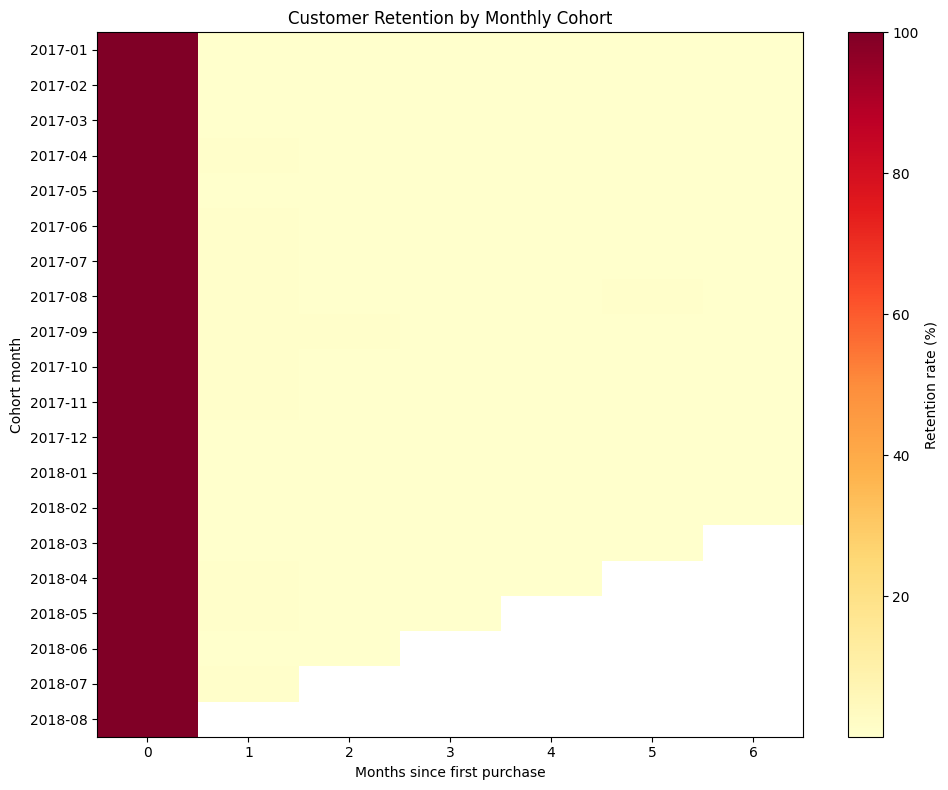

In [6]:
plt.figure(figsize=(10, 8))
plt.imshow(pivot, cmap='YlOrRd', aspect='auto')
plt.colorbar(label='Retention rate (%)')
plt.xlabel('Months since first purchase')
plt.ylabel('Cohort month')
plt.yticks(range(len(pivot.index)), [str(d)[:7] for d in pivot.index])
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.title('Customer Retention by Monthly Cohort')
plt.tight_layout()
plt.show()

**Key finding**: Retention drops sharply after month 0 across all cohorts, 
with month-1 retention consistently below 1%. This confirms the low 
repeat-purchase rate identified earlier (~3% overall) and shows the 
pattern holds consistently across acquisition periods, not just as an 
isolated anomaly, which is reinforcing the case for proactive CRM reactivation 
rather than relying on organic repeat purchases.